# BME Lab 114 — Morphology-Elasticity Relationship of Trabecular Bone

**Author:** Simone Poncioni, MSB  
**Date:** Spring Semester 2026

---

## Notebook 4: Post-processing

The CalculiX solver has produced a `.frd` results file containing nodal displacements, reaction forces, and element stresses. In this final notebook, we extract these results and use them to compute two key quantities:

1. The **apparent elastic modulus** $E_\text{app}$ — a measure of the overall stiffness of the trabecular structure
2. The **bone volume fraction** BV/TV — the primary morphological descriptor of trabecular bone density

Finally, we visualise the stress and strain fields across the mesh to gain intuition about how load is distributed through the trabecular network.

### 0. Imports

In [1]:
from pathlib import Path
import ccx2paraview
import pyvista as pv
import numpy as np
import meshio
import pandas as pd
import os

### 1. Convert CalculiX Output to VTK

The solver writes results in its native `.frd` binary format. We first convert it to `.vtk` using `ccx2paraview`, which makes the data readable by PyVista and other visualisation tools.

We also read the `.dat` file, which contains the **printed scalar outputs** requested in the simulation template — in our case, the total reaction force at the bottom face (`RF` at `NODES_Z0`).

In [2]:
filename_frd = Path("/home/bmelab/bmelabs/2026/testing/MSB_BMELab/114-MorphologyElasticityTrabecularBone/muFE/00_DATA/group01/A1/derived/C0004351_segmented.frd")
filename_dat = filename_frd.with_suffix(".dat")
filename_vtk = filename_frd.with_suffix(".vtk")
filename_np = filename_frd.with_suffix(".npy")

ccx2paraview.Converter(str(filename_frd.resolve()), ['vtk']).run()

The `.dat` file contains the sum of reaction forces at the fixed boundary. Read it carefully — you will need the total reaction force $F$ to compute the apparent elastic modulus in the next step.

In [3]:
!cat {filename_dat}


 total force (fx,fy,fz) for set NODES_Z0 and time  0.1000000E+01

        2.613217E-11  5.915227E-12  5.362209E+02


### 2. Calculate the Apparent Elastic Modulus

The apparent elastic modulus is defined as:

$$E_\text{app} = \frac{\sigma}{\varepsilon} = \frac{F / A}{\Delta u / L}$$

Where:
- $F$ — total reaction force at the fixed face [N], read from the `.dat` file
- $A$ — cross-sectional area of the sample [mm²], computed from the mesh bounding box
- $\Delta u$ — applied displacement [mm], as defined in the simulation template
- $L$ — height of the sample along the loading axis [mm]

> **Task:** Complete the code below to extract $F$, $A$, $L$, and compute $E_\text{app}}$.

> **Reference:** [`np.loadtxt`](https://numpy.org/doc/stable/reference/generated/numpy.loadtxt.html), [`np.sum`](https://numpy.org/doc/stable/reference/generated/numpy.sum.html)

In [4]:
"""
# TODO: Read the total reaction force F from filename_dat
# Hint: open and inspect the file first with: print(open(filename_dat).read())
# Then use np.loadtxt() to parse the numeric values and sum the RF components
F = ...  # [N]

# TODO: Input the cross-sectional area A of the sample
A = ...  # [mm²]

# TODO: Compute the height L of the sample along the loading axis (Z)
# Hint: L = zmax - zmin
L = ...  # [mm]

# Applied displacement from the simulation template
delta_u = - 0.01  # [mm]

# TODO: Compute apparent strain, stress, and elastic modulus
epsilon = ...        # strain [-] = delta_u / L
sigma   = ...        # stress [MPa] = F / A
E_app   = ...        # modulus [MPa] = sigma / epsilon

print(f"Reaction force F     = {F:.4f} N")
print(f"Cross-section A      = {A:.4f} mm²")
print(f"Sample height L      = {L:.4f} mm")
print(f"Apparent strain ε    = {epsilon:.6f}")
print(f"Apparent stress σ    = {sigma:.4f} MPa")
print(f"Apparent modulus E   = {E_app:.2f} MPa")
"""

'\n# TODO: Read the total reaction force F from filename_dat\n# Hint: open and inspect the file first with: print(open(filename_dat).read())\n# Then use np.loadtxt() to parse the numeric values and sum the RF components\nF = ...  # [N]\n\n# TODO: Input the cross-sectional area A of the sample\nA = ...  # [mm²]\n\n# TODO: Compute the height L of the sample along the loading axis (Z)\n# Hint: L = zmax - zmin\nL = ...  # [mm]\n\n# Applied displacement from the simulation template\ndelta_u = - 0.01  # [mm]\n\n# TODO: Compute apparent strain, stress, and elastic modulus\nepsilon = ...        # strain [-] = delta_u / L\nsigma   = ...        # stress [MPa] = F / A\nE_app   = ...        # modulus [MPa] = sigma / epsilon\n\nprint(f"Reaction force F     = {F:.4f} N")\nprint(f"Cross-section A      = {A:.4f} mm²")\nprint(f"Sample height L      = {L:.4f} mm")\nprint(f"Apparent strain ε    = {epsilon:.6f}")\nprint(f"Apparent stress σ    = {sigma:.4f} MPa")\nprint(f"Apparent modulus E   = {E_app:.2f}

In [5]:
mesh = meshio.read(filename_vtk)

# Get bounding box from mesh points
points = mesh.points  # shape (N, 3) → columns: X, Y, Z
L = points[:, 2].max() - points[:, 2].min()  # height along Z [mm]

F = 5.362209e2
A = 15  # mm²
delta_u = -0.01  # [mm]

epsilon = delta_u / L
sigma   = F / A
E_app   = sigma / epsilon
stiffness = F / delta_u

print(f"Reaction force F     = {F:.4f} N")
print(f"Cross-section A      = {A:.4f} mm²")
print(f"Sample height L      = {L:.4f} mm")
print(f"Stiffness            = {stiffness:.2f} N/mm")
print(f"Apparent strain ε    = {epsilon:.6f}")
print(f"Apparent stress σ    = {sigma:.4f} MPa")
print(f"Apparent modulus E   = {E_app:.2f} MPa")

Reaction force F     = 536.2209 N
Cross-section A      = 15.0000 mm²
Sample height L      = 14.8605 mm
Stiffness            = -53622.09 N/mm
Apparent strain ε    = -0.000673
Apparent stress σ    = 35.7481 MPa
Apparent modulus E   = -53123.41 MPa


### 3. Calculate Bone Volume Fraction (BV/TV)

Bone Volume Fraction (BV/TV) is the ratio of mineralised bone volume to the total volume of the region of interest. It is the single most important morphological predictor of trabecular bone stiffness.

$$\text{BV/TV} = \frac{\text{Number of bone voxels}}{\text{Total number of voxels in ROI}}$$

> **Task:** Complete the code below to compute BV/TV from the segmented image `bone_arr` produced in Notebook 1.  
> **Reference:** [`np.sum`](https://numpy.org/doc/stable/reference/generated/numpy.sum.html), [`np.prod`](https://numpy.org/doc/stable/reference/generated/numpy.prod.html), [`ndarray.shape`](https://numpy.org/doc/stable/reference/generated/numpy.ndarray.shape.html)

In [6]:
bone_np = np.load(filename_np)

# Calculate TV (total number of voxels in the bounding box)
TV = np.prod(bone_np.shape)

# Calculate BV (number of bone voxels, where bone = 1)
BV = np.sum(bone_np)

# Calculate BV/TV
BVTV = BV / TV

print(f"TV       = {TV} voxels")
print(f"BV       = {BV} voxels")
print(f"BV/TV    = {BVTV:.4f}  ({BVTV * 100:.2f} %)")

TV       = 93995235 voxels
BV       = 28344004 voxels
BV/TV    = 0.3015  (30.15 %)


In [7]:
mesh = pv.read(filename_vtk)
print(mesh.array_names)  # shows available scalar arrays

['U', 'S', 'S_Mises', 'S_Principal', 'E', 'E_Mises', 'E_Principal', 'ERROR']


2026-03-03 14:45:34.138 (  20.620s) [    7F61138F9540]vtkXOpenGLRenderWindow.:1458  WARN| bad X server connection. DISPLAY=
nvc0_screen_create:1002 - Base screen init failed: -19
libEGL warning: egl: failed to create dri2 screen
nvc0_screen_create:1002 - Base screen init failed: -19
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

2026-03-03 14:45:34.163 (  20.645s) [    7F61138F9540] vtkEGLRenderWindow.cxx:359   WARN| vtkEGLRenderWindow (0x279c5e80): EGL device index: 0 could not be initialized. Trying other devices...
nvc0_screen_create:1002 - Base screen init failed: -19
libEGL warning: egl: failed to create dri2 screen
nvc0_screen_create:1002 - Base screen init failed: -19
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

2026-03-03 14:45:34.178 (  20.660s) [    7F61138F9540] vtkEGLRenderWindow.cxx:359   WARN| vtkEGLRenderWindow (0x24032280): EGL devi

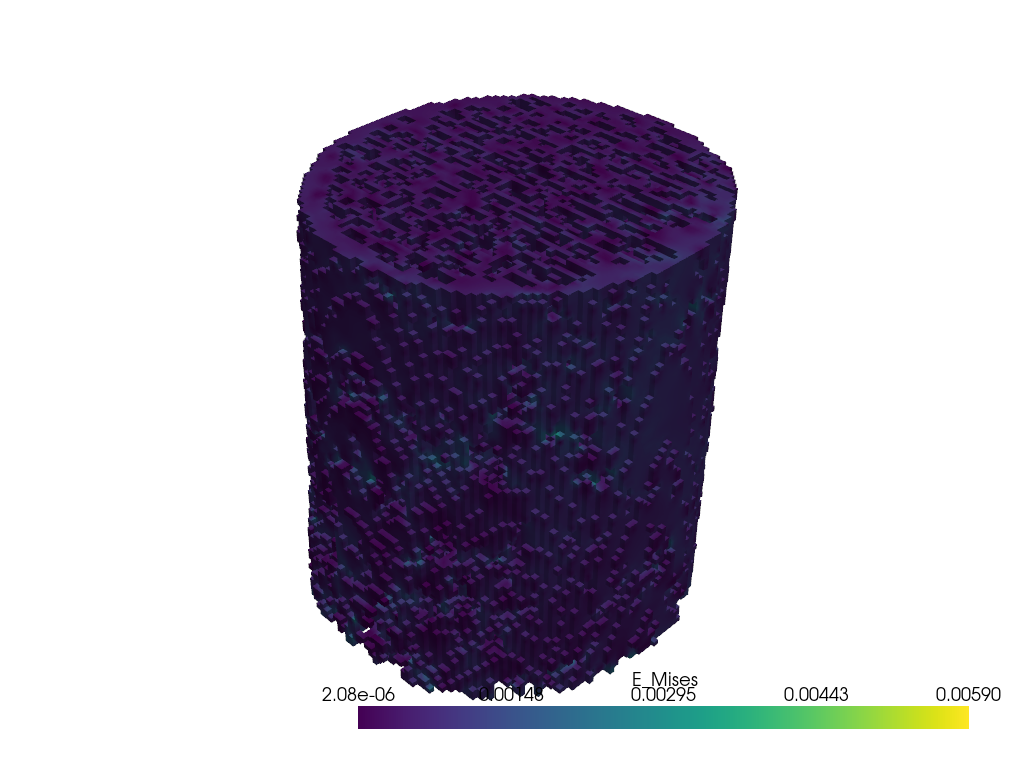

In [8]:
# Opens interactive viewer in browser/Jupyter cell
pl = pv.Plotter(notebook=True)
pl.add_mesh(mesh, scalars="E_Mises", cmap="viridis")
pl.show()

In [15]:
row = {
    "sample": filename_frd.name.split("_")[0],
    "bvtv": BVTV,
    "reaction_force_N": round(F, 4),
    "stiffness_Nmm": round(stiffness, 2),
    "app_strain": round(epsilon, 6),
    "app_stress_mpa": round(sigma, 4),
    "app_modulus_mpa": round(E_app, 2)
}

output_path = "../../02_RESULTS/results_group01.tsv"
df = pd.DataFrame([row])

# Write header only if file doesn't exist yet
df.to_csv(output_path, mode='a', header=not os.path.exists(output_path), index=False, sep = '\t', encoding='utf-8')